# Phase 1 Student Notebook: Simple Multi-Agent Orchestration

Goal: Understand a minimal multi-agent workflow using LangGraph.

## LangGraph Basics (State, Nodes, Edges)

**LangGraph** lets us build workflows as a **state machine**.

### Key Ideas
- **State** = shared memory passed between agents.
- **Node** = a function (agent) that updates state.
- **Edge** = the path between nodes.
- **Conditional Edge** = a decision (if/else) based on state.

### Flow of Information
```
User Question
    ↓
Supervisor Agent (decides route)
    ↓
Math Specialist (if math) → Final Response
    ↓
User Answer
```

Keep this in mind as we build each part below.

## 1. Imports

Run this cell first.

In [1]:
# STEP 1: Imports
# Why: We need LangGraph for orchestration and LangChain for message types.
# Hint: Load .env so OPENAI_API_KEY is available.
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph, MessagesState
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from typing import Any, Literal

import json

d:\Mentoring\learwithsarvesh\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


StateGraph:
Supervisor -> Math Agent -> Final Agent

MessageState:
- Store the user messages
- Agent Replies
- Tool Outputs

## 2. LLM (Supervisor uses this)

Only the supervisor agent calls the LLM.

In [2]:
# STEP 2: Initialize the LLM
# Why: Only the supervisor uses the LLM to make routing decisions.
# Hint: temperature=0 makes it deterministic.

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 3. Math Tools

In [3]:
# STEP 3: Math Tools
# Why: Specialists call tools instead of LLMs for simple tasks.
# Hint: Keep tools pure and deterministic.
# TODO: define add_numbers(a, b)
# TODO: define multiply_numbers(a, b)
# TODO: create MATH_TOOLS dict mapping names to functions

def add_numbers(a: int, b: int) -> int:
    """Add two numbers togeather"""
    result = a + b
    print(f"Tool: {a} + {b} = {result}")
    return result

def multiply_numbers(a: int, b: int) -> int:
    """Multiply two numbers togeather"""
    result = a * b
    print(f"Total: {a} x {b} = {result}")
    return result

# Tool Registry:
MATH_TOOLS = {
    "add_numbers": add_numbers,
    "multiply_numbers": multiply_numbers
}

1. Tools are a simple python functions
2. The Specialist chooses which tool to call bsed on the Supervisor decision
3. This mirrors real agents calling external tools/ API's

## 4. Supervisor Agents

### Quick Intuition: What is `state`?

Think of `state` as a plain Python dictionary that travels between agents.
Each agent reads it, adds new information, and passes it forward.

Simple example:
```python
state = {
    "messages": [HumanMessage(content="What is 2 plus 2?")]
}
messages = state.get("messages", [])  # safe read with fallback
```

- If `messages` exists, you get the list.
- If it does not, you get an empty list instead of an error.

This keeps agents simple: read from `state`, update `state`, return `state`.

In [4]:
# STEP 4: Agents
# Why: Agents are functions that read state, do work, and write state.
# Hint: Each agent must return the updated state.
# TODO: define supervisor_agent(state)
#   - read messages
#   - call llm with prompt
#   - parse JSON decision
#   - save decision + message to state
# TODO: define math_specialist_agent(state)
#   - read supervisor_decision
#   - call tool
#   - save math_result + ToolMessage to state
# TODO: define final_response_agent(state)
#   - format final_answer based on math_result
#   - save final_answer to state

def supervisor_agent(state: dict) -> dict:
    """
    Supervisor Agent: Reads the user question and decides what to do.
    Flow:
    1. Read the user's question from messages
    2. Ask LLM to analyze the question
    3. Get routing decision (math or not)
    4. Save decision to State
    """
    print("\n Supervisor: Analyzing Question")

    # Get the Conv history from state
    messages = state.get("messages", [])

    supervisor_prompt = """You are a supervisor agent managing a team of specialists.

You have access to:
- Math Specialist: Can add numbers or multiply numbers

Your job is to read the user's question and decide:
1. Is this asking to add/sum numbers? (keywords: plus, add, sum, total, +)
2. Is this asking to multiply numbers? (keywords: multiply, times, product, *)
3. If either: route to math_specialist
4. If neither: respond cannot_help

EXAMPLES:
- "What is 5 plus 3?" -> {"decision": "route_to_specialist", "specialist": "math_specialist", "operation": "add_numbers", "parameters": {"a": 5, "b": 3}}
- "Multiply 7 and 6" -> {"decision": "route_to_specialist", "specialist": "math_specialist", "operation": "multiply_numbers", "parameters": {"a": 7, "b": 6}}
- "What is the meaning of life?" -> {"decision": "cannot_help", "reason": "This is not a math question"}

IMPORTANT: Respond ONLY with the JSON object. No explanation, no markdown code blocks."""

    response = llm.invoke(messages + [SystemMessage(content = supervisor_prompt)])
    supervisor_message = response.content

    # Parse the JSON decision:
    decision = json.loads(supervisor_message) # 

    # Save to State:
    messages.append(AIMessage(content = supervisor_message, name = "supervisor"))
    state['messages'] = messages
    state['supervisor_decision'] = decision

    print(f"Decision: {decision['decision']}")

    return state

{"decision": "route_to_specialist", "specialist": "math_specialist", "operation": "add_numbers", "parameters": {"a": 5, "b": 3}}

1. SystemMessage
2. HumanMessage
3. AIMessage

In [5]:
## '{"key": "value"}' -> {"key": "value"}

## json to dict (json.loads())

### Math Specialist Agent

The Math Specialist reads the supervisor decision, calls the tools, and saves the result

- Supervisor agent -> decides
- Specialist agent -> executes

State contains:
- Routing decision
- Which Specilist
- Operation
- Parameters

all these updated by the supervisor

Specialist - cares only about how to do, not worried about what to do

{"decision": "route_to_specialist", "specialist": "math_specialist", "operation": "add_numbers", "parameters": {"a": 5, "b": 3}}

In [6]:
def math_specialist_agent(state: dict) -> dict:
    """
    Math Specialist Agent: Executes Math Operations.

    Flow:
    1. Read the supervisor's decision
    2. Get Operation (add or multiply) and parameters
    3. Call the math tool
    4. Save result to state
    """
    print("\n Math Specialist: Doing the Math prob ...")

    # Get the routing decision from supervisor:
    decision = state.get("supervisor_decision", {})
    operation = decision.get("operation")
    parameters = decision.get("parameters", {})

    print(f" Operation: {operation}")
    print(f" Paramters: {parameters}")

    tool_func = MATH_TOOLS[operation]

    result = tool_func(**parameters) ## **parameter -> unpacks dict into function arguments:

    ## Add results to messages:
    result_message = ToolMessage(
        content=f"Math operation result:{result}",
        tool_call_id=operation,
        name="math_specialist"
        )

    messages = state.get("messages", [])   
    messages.append(result_message)
    
    # Save to state:
    state['messages'] = messages
    state['math_result'] = result

    print(f"Result:{result}")
    return state

State has the Memory and also pass on the memory to others as well -> Its like a data bus

ToolMessage:
1. SystemMessage/ AIMEssgae/ HumanMessage
2. ToolMessage 

Defining the shared memory that flows through all agents.

OrchestratorClass State

supervisor_decision: dict = {}

## Final Response Agent

In [7]:
def final_response_agent(state: dict) -> dict:
    """    
    1. Check if we have a math result?
    2. Format it back to a nicely constructed answer
    3. Save to state
    """
    # Get from the State:
    math_result = state.get("math_result")

    # Format the answer:
    if math_result is not None:
        final_answer = f"The answer is: {math_result}"
    else:
        final_answer = "I couldn't solve this problem"
    
    # Save to state:
    state['final_answer'] = final_answer

    print(f" Final Answer: {final_answer}\n")

    return state

## Orchestrator State

Define the shared memory that flows through all agents.

Agents dont pass the variables, they just pass the state

- We are creating a custom state, it inherits from **MessageState**, its automatically get messages list, messages handling logic.
- MessageState give us conversation memory for free.

Why do I need this custom state?
1. Agents share decisions, numbers, flags, results;

State is a shared whiteboard for agents;

ToolMessage
SystemMessage
AIMessage
UserMessage

These are useful for debugging purposes; 

{"decision": "route_to_specialist", "specialist": "math_specialist", "operation": "add_numbers", "parameters": {"a": 5, "b": 3}}

We dont want the edges to think rather they simply read from state

If I have this custom class, the Schema is setup, self-documenting, Safer Routing;

In [8]:
class OrchestratorState(MessagesState):
    """
    State that flows through all agents.

    messages (from MessageState): Conversation History
    supervisor_decision: Supervisor's routing decision
    math_result: numeric result from the math tool
    final_answer: Well formatted answer for the end user
    """

    supervisor_decision: dict = {}
    next_agent: str = ""
    math_result: Any = None
    final_answer: str = ""

## 5. State and Routing

In [9]:
# STEP 5: State and Routing
# Why: State is shared memory; routing decides next agent.
# Hint: Use MessagesState so messages are included.
# TODO: define OrchestratorState(MessagesState) with fields:
#   supervisor_decision, next_agent, math_result, final_answer
# TODO: define route_after_supervisor(state)
#   - if decision is route_to_specialist -> math_specialist
#   - else -> final_response

1. This is a normal function, not a custom class not an agnet
2. This is a routing logic
3. LangGraph uses this to decide which node runs next

This function is like a traffic signal to the graph

- I am forcing the function only to have a valid node names
- i want to prevent routing errors
- This makes the graph safer

In [10]:
def route_after_supervisor(state: OrchestratorState) -> Literal['math_specialist', 'final_response']:
    """
    Decide who goes next based on supervisor decision.
    Return value Must be one of the two diff node names (math_specialist, final_response)
    """

    decision = state.get("supervisor_decision", {})

    if decision.get('decision') == "route_to_specialist":
        return "math_specialist"
    else:
        return "final_response"

## 6. Build and Run

In [11]:
# STEP 6: Build and Run
# Why: This wires agents into a LangGraph state machine.
# Hint: Entry point = supervisor, finish point = final_response.
# TODO: define build_orchestrator()
#   - add nodes: supervisor, math_specialist, final_response
#   - set entry point
#   - add conditional edges using route_after_supervisor
#   - add edge math_specialist -> final_response
#   - compile and return app
# TODO: define run_orchestrator(question)
#   - create initial_state with HumanMessage
#   - app.invoke(initial_state)
#   - print final answer
# TODO: test with 3 questions

- We build the System
- It builds and returns a compiled LangGrapgh app 


Assemble -> wire -> compile -> return

State Machine:
- Execution moves from node to node.
- Based on state
- Until a finish point is reached

LangGraph is a state-driven workflow engine.

- A node is an agent -> a python function
- It accepts state
- Returns updated state

In [12]:
def build_orchestrator():
    """
    Build the LangGraph orchestrator (State Machine).
    """

    graph = StateGraph(OrchestratorState) # We tell LangGraph -> This is the structure of my shared state;

    ## Add the agents as nodes:
    graph.add_node("supervisor", supervisor_agent)
    graph.add_node("math_specialist", math_specialist_agent)
    graph.add_node("final_response", final_response_agent)

    # Entry point:
    graph.set_entry_point("supervisor")
    
    # Conditional routing after supervisor
    graph.add_conditional_edges(
        "supervisor", # Step1 is done
        route_after_supervisor, # Step2 -> Routing after the supervisor
        {
            "math_specialist": "math_specialist",
            "final_response": "final_response"
        }
    )

    # Always after the math_specialist goto the final_response:
    graph.add_edge("math_specialist", "final_response")

    # End the grapgh at final response:
    graph.set_finish_point("final_response")

    # Compile into Runnable app:
    app = graph.compile()
    #print(app.get_graph().draw_ascii())
    return app

In [13]:
# Build the orchestrator and visualize the graph
app = build_orchestrator()
print(app.get_graph().draw_ascii())

                 +-----------+         
                 | __start__ |         
                 +-----------+         
                       *               
                       *               
                       *               
                +------------+         
                | supervisor |         
                +------------+         
                ..            ..       
              ..                ..     
            ..                    ..   
+-----------------+                 .. 
| math_specialist |               ..   
+-----------------+             ..     
                **            ..       
                  **        ..         
                    **    ..           
              +----------------+       
              | final_response |       
              +----------------+       
                       *               
                       *               
                       *               
                  +---------+          


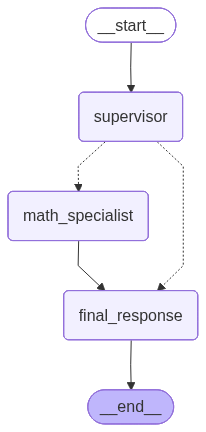

In [14]:
from IPython.display import Image, display

# Generate Mermaid diagram as PNG
mermaid_png = app.get_graph().draw_mermaid_png()
display(Image(mermaid_png))

Compile:
1. Validate graph Structure
2. Locks node names
3. Makes it executable

# Run the Orchestrator:

1. Takes on user question
2. It runs through the entire LangGraph
3. Prints the result and returns the result as well 

Using this we build once, run as many times as possible

In [15]:
def run_orchestrator(user_question: str):
    """
    Run the orchestrator for one question
    """
    print(f"Question: {user_question}")

    # Build the graph:
    app = build_orchestrator() # Creates a fresh compiled graph, includes: 1. agents, 2. routing, 3. state schema | Agents, routing, state schema -> Clean, stateless, reusuable arch

    # Create initial state with user function:
    initial_state = OrchestratorState(
        messages = [HumanMessage(content=user_question)]
    )

    # Run the graph:
    final_state = app.invoke(initial_state)

    # Print the Final Result:
    print(f"Final Answer: {final_state.get('final_answer')}")

    return final_state

In [16]:
test_questions = [
    "What is 5 times 3?",
    "What is 19 plus 2",
    "What is the meaning of life?"
]

for i in test_questions:
    run_orchestrator(i)

Question: What is 5 times 3?

 Supervisor: Analyzing Question
Decision: route_to_specialist

 Math Specialist: Doing the Math prob ...
 Operation: multiply_numbers
 Paramters: {'a': 5, 'b': 3}
Total: 5 x 3 = 15
Result:15
 Final Answer: The answer is: 15

Final Answer: The answer is: 15
Question: What is 19 plus 2

 Supervisor: Analyzing Question
Decision: route_to_specialist

 Math Specialist: Doing the Math prob ...
 Operation: add_numbers
 Paramters: {'a': 19, 'b': 2}
Tool: 19 + 2 = 21
Result:21
 Final Answer: The answer is: 21

Final Answer: The answer is: 21
Question: What is the meaning of life?

 Supervisor: Analyzing Question
Decision: cannot_help
 Final Answer: I couldn't solve this problem

Final Answer: I couldn't solve this problem


llama
token usge monotring
optimisation